# Analytic Question

**Are forwards fouled more often than defenders per 90 minutes played?**

Fouls drawn show how often an opponent commits a foul against a player. We expect forwards to be fouled more often because they usually receive the ball while facing the goal and are under pressure from defenders. This can happen in dangerous areas where defenders may choose to commit a foul rather than let the forward continue. Defenders, on the other hand, are more likely to win the ball without committing a foul, or the players themselves may commit the fouls.

The comparison is based on fouls drawn per 90 minutes rather than the total number of fouls. This is because players had very different amounts of playing time, ranging from 1 to 810 minutes (Emiliano Martinez, Argentina's goalkeeper, played the full 810 minutes in all 8 of their matches). Using the total number of fouls would therefore be affected by how much time each player spent on the field.

**Population:** Forwards and defenders who played at least 90 minutes at the 2026 World Cup. Players who played less than 90 minutes were excluded because their per-90 rate could be unreliable. For example, if a player was fouled once during a 10-minute appearance, that would equate to a rate of 9 fouls drawn per 90 minutes.

**Test:** A two-tailed test will be used. Although we expect forwards to be fouled more often, the test will not assume this direction.


## Data Wrangling

The data comes from the cleaned FBref player export, which combines the Standard, Shooting, Playing Time and Miscellaneous pages for the tournament. Before creating the main variable for the analysis, a few things need to be fixed. The squad names have a country-code prefix left over from the flag information; some players have more than one position listed in the same string; and fouls drawn are given as a total count, so it needs to be converted to a rate per 90 minutes.

In [1]:
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
RANDOM_STATE = 42

players = pd.read_csv("processed/players_clean.csv")
df = players.copy()
print(f"Rows loaded: {len(df)}")

# FBref adds a country code before some squad names, so remove it to make the
# team names consistent.
COUNTRY_CODE = re.compile(r"^([a-z]{2,3})\s+|\s+([a-z]{2,3})$")
df["squad"] = df["squad"].astype(str).apply(lambda s: COUNTRY_CODE.sub("", s).strip())

# Some players have two positions listed, such as "FW,MF". We use the first
# position because it is the player's main position according to FBref.
df["pos_primary"] = df["pos"].astype(str).str.split(",").str[0].str.strip()

df["minutes"]     = pd.to_numeric(df["minutes"], errors="coerce")
df["nineties"]    = df["minutes"] / 90
df["fouls_drawn"] = pd.to_numeric(df["misc_performance_fld"], errors="coerce")

# Calculate the number of fouls drawn per 90 minutes. Players who did not play
# any minutes are given NaN because their rate cannot be calculated.
df["fouls_drawn_per90"] = np.where(df["nineties"] > 0,
                                   df["fouls_drawn"] / df["nineties"], np.nan)

print(f"\nNever appeared (removed):     {(df['minutes'] == 0).sum()}")
print(f"Retained with pitch time:     {(df['minutes'] > 0).sum()}")
print(f"Total fouls drawn recorded:   {int(df['fouls_drawn'].sum())}")

# Check that our calculation of 90s is the same as the 90s value provided by FBref.
print(f"Rate check vs FBref's own 90s column, max difference: "
      f"{(df['nineties'] - df['misc_90s']).abs().max():.4f}")

print("\nMinutes played:")
print(df["minutes"].describe().round(1).to_string())

print("\nPlayers by primary position:")
print(df["pos_primary"].value_counts().to_string())

# Look at the players with the highest rates to make sure the results seem
# reasonable and the variable is measuring fouls drawn correctly.
print("\nMost-fouled players (validity check):")
check = df[df["minutes"] >= 270].nlargest(5, "fouls_drawn_per90")
print(check[["player","pos","squad","minutes","fouls_drawn","fouls_drawn_per90"]]
      .round(2).to_string(index=False))

Rows loaded: 1039

Never appeared (removed):     0
Retained with pitch time:     1039
Total fouls drawn recorded:   2308
Rate check vs FBref's own 90s column, max difference: 0.0444

Minutes played:
count    1039.0
mean      203.5
std       158.4
min         1.0
25%        71.0
50%       180.0
75%       288.0
max       810.0

Players by primary position:
pos_primary
MF    392
DF    349
FW    236
GK     62

Most-fouled players (validity check):
         player   pos       squad  minutes  fouls_drawn  fouls_drawn_per90
    Jeremy Doku    MF     Belgium      309           18               5.24
Hannibal Mejbri    MF     Tunisia      270           15               5.00
Martin Baturina MF,FW     Croatia      321           14               3.93
  Jamal Musiala    MF     Germany      270           11               3.67
      Dan Ndoye MF,FW Switzerland      406           16               3.55


## Data Preparation and Sampling

The population includes all forwards and defenders who played at least 90 minutes. Midfielders and goalkeepers were excluded because the research question only compares forwards and defenders. The 90-minute minimum was used to avoid including players whose fouls-per-90 rate could be affected by only a small amount of playing time.

A stratified random sample was used for the analysis. This means that forwards and defenders were sampled separately so that both groups were properly represented. If a random sample were taken from the whole group, it could accidentally include too few forwards or defenders, making the results less reliable.

For each position, 70% of the players were randomly selected, with a minimum of 30 players from each group. This provides a large enough sample for the Central Limit Theorem to apply when comparing the group means in the statistical test.

In [2]:
MIN_MINUTES = 90   # one full match

population = df[(df["minutes"] >= MIN_MINUTES) &
                (df["pos_primary"].isin(["FW", "DF"]))].dropna(subset=["fouls_drawn_per90"])

print(f"Population N = {len(population)}   {population['pos_primary'].value_counts().to_dict()}")
print(f"Excluded for under {MIN_MINUTES} minutes: "
      f"{((df['pos_primary'].isin(['FW','DF'])) & (df['minutes'] < MIN_MINUTES)).sum()}")

SAMPLE_FRACTION, MIN_PER_GROUP = 0.70, 30

parts = []
for group, subset in population.groupby("pos_primary"):
    n = min(max(MIN_PER_GROUP, round(len(subset) * SAMPLE_FRACTION)), len(subset))
    if n < MIN_PER_GROUP:
        print(f"  below the {MIN_PER_GROUP}-observation floor: {group}")
    parts.append(subset.sample(n=n, random_state=RANDOM_STATE))

# Shuffled so the sample is not ordered by position.
sample = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"\nSample n = {len(sample)}   {sample['pos_primary'].value_counts().to_dict()}")

# A sample is only useful if it resembles the population it was drawn from.
print("\nRepresentativeness:")
for group in ["FW", "DF"]:
    p = population.loc[population["pos_primary"] == group, "fouls_drawn_per90"]
    s = sample.loc[sample["pos_primary"] == group, "fouls_drawn_per90"]
    print(f"  {group}: population mean {p.mean():.4f} (sd {p.std():.4f}) | "
          f"sample mean {s.mean():.4f} (sd {s.std():.4f}) | "
          f"deviation {abs(s.mean() - p.mean()) / p.mean() * 100:.2f}% | "
          f"{len(s) / len(p) * 100:.1f}% sampled")

forwards  = sample.loc[sample["pos_primary"] == "FW", "fouls_drawn_per90"]
defenders = sample.loc[sample["pos_primary"] == "DF", "fouls_drawn_per90"]

Population N = 373   {'DF': 261, 'FW': 112}
Excluded for under 90 minutes: 212

Sample n = 261   {'DF': 183, 'FW': 78}

Representativeness:
  FW: population mean 1.3357 (sd 0.7830) | sample mean 1.2916 (sd 0.6882) | deviation 3.30% | 69.6% sampled
  DF: population mean 0.6766 (sd 0.6896) | sample mean 0.6973 (sd 0.7056) | deviation 3.06% | 70.1% sampled


## Descriptive Statistics

The sample is described using both the mean and median because the data for the two groups is not evenly distributed. Skewness and the coefficient of variation are also included because they give more information than just the mean. Skewness shows whether the data is unevenly distributed, while the coefficient of variation shows how much the values vary compared to the average.

               n   mean  median     sd  min    max     q1     q3   skew    iqr     cv
pos_primary                                                                          
DF           183  0.697   0.526  0.706  0.0  3.429  0.000  1.000  1.418  1.000  1.012
FW            78  1.292   1.246  0.688  0.0  3.313  0.752  1.722  0.618  0.969  0.533

Players never fouled:
  FW: 1 of 78 (1.3%)
  DF: 47 of 183 (25.7%)


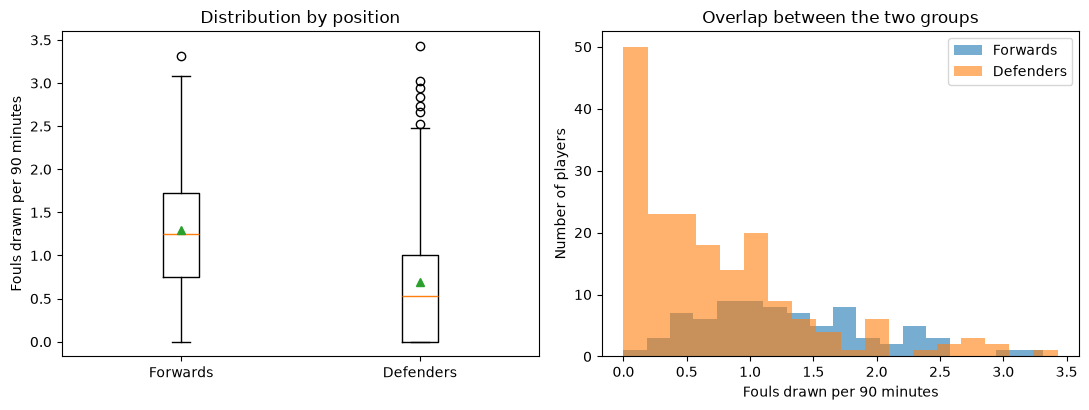

In [3]:
desc = sample.groupby("pos_primary")["fouls_drawn_per90"].agg(
    n="count", mean="mean", median="median", sd="std", min="min", max="max",
    q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75), skew="skew")
desc["iqr"] = desc.q3 - desc.q1
desc["cv"]  = desc.sd / desc["mean"]     # relative spread, comparable across groups
print(desc.round(3).to_string())

# A quarter of defenders were never fouled at all, which is what drives the skew
# and the zero first quartile.
print("\nPlayers never fouled:")
for group in ["FW", "DF"]:
    s = sample.loc[sample["pos_primary"] == group, "fouls_drawn_per90"]
    print(f"  {group}: {(s == 0).sum()} of {len(s)} ({(s == 0).mean() * 100:.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].boxplot([forwards, defenders], tick_labels=["Forwards", "Defenders"], showmeans=True)
ax[0].set_ylabel("Fouls drawn per 90 minutes")
ax[0].set_title("Distribution by position")

for data, label in [(forwards, "Forwards"), (defenders, "Defenders")]:
    ax[1].hist(data, bins=18, alpha=0.6, label=label)
ax[1].set_xlabel("Fouls drawn per 90 minutes")
ax[1].set_ylabel("Number of players")
ax[1].set_title("Overlap between the two groups")
ax[1].legend()

plt.tight_layout()
plt.savefig("fouls_drawn_by_position.png", dpi=150)
plt.show()

## Inferential Statistics: Two-Sample t-Test

Welch's two-sample t-test is used instead of the standard Student's t-test. Levene's test does not show a significant difference between the variances, but this does not guarantee that the variances are equal. Welch's test is a safer option because it still works well even when the variances are similar.

A Mann-Whitney U test is also used as a second check. This test does not require the data to follow a particular distribution, so it helps confirm whether the t-test results are consistent.

In [4]:
n_f, n_d = len(forwards), len(defenders)
var_f, var_d = forwards.var(ddof=1), defenders.var(ddof=1)

# Welch-Satterthwaite degrees of freedom.
dof = (var_f/n_f + var_d/n_d)**2 / ((var_f/n_f)**2/(n_f-1) + (var_d/n_d)**2/(n_d-1))

print("ASSUMPTION CHECKS")
for label, data in [("Forwards", forwards), ("Defenders", defenders)]:
    sw = stats.shapiro(data)
    print(f"  Shapiro-Wilk {label:<10} W={sw.statistic:.4f}  p={sw.pvalue:.2e}  "
          f"skew={stats.skew(data):.2f}")

lev = stats.levene(forwards, defenders, center="median")
print(f"  Levene (equal variance)  stat={lev.statistic:.3f}  p={lev.pvalue:.4f}")

print("\nWELCH TWO-SAMPLE t-TEST")
print("  H0: forwards and defenders are fouled at the same rate per 90 minutes")
print("  H1: the rates differ                                    (two-tailed, a = 0.05)")

t_stat, p_value = stats.ttest_ind(forwards, defenders, equal_var=False)
pooled_sd = np.sqrt(((n_f-1)*var_f + (n_d-1)*var_d) / (n_f + n_d - 2))

print(f"\n  t = {t_stat:.4f}   df = {dof:.1f}   p = {p_value:.3e}")
print(f"  Difference in means = {forwards.mean() - defenders.mean():.4f} fouls per 90")
print(f"  Cohen's d = {(forwards.mean() - defenders.mean()) / pooled_sd:.3f}")

mw = stats.mannwhitneyu(forwards, defenders, alternative="two-sided")
print(f"  Mann-Whitney U cross-check: U={mw.statistic:.0f}, p={mw.pvalue:.3e}")
print("\n  p < 0.05, so H0 is rejected.")

ASSUMPTION CHECKS
  Shapiro-Wilk Forwards   W=0.9662  p=3.61e-02  skew=0.61
  Shapiro-Wilk Defenders  W=0.8567  p=4.03e-12  skew=1.41
  Levene (equal variance)  stat=0.267  p=0.6057

WELCH TWO-SAMPLE t-TEST
  H0: forwards and defenders are fouled at the same rate per 90 minutes
  H1: the rates differ                                    (two-tailed, a = 0.05)

  t = 6.3383   df = 148.8   p = 2.620e-09
  Difference in means = 0.5943 fouls per 90
  Cohen's d = 0.849
  Mann-Whitney U cross-check: U=10797, p=4.827e-11

  p < 0.05, so H0 is rejected.


## Findings

The results show that forwards are fouled about twice as often as defenders. In the sample, forwards drew an average of 1.292 fouls per 90 minutes, compared with 0.697 for defenders. This gives a difference of 0.594 fouls per 90 minutes.

The Welch two-sample t-test gave a result of **t = 6.34**, with **148.8 degrees of freedom** and **p = 2.6 × 10⁻⁹**. Since the p-value is very small, the null hypothesis that the two groups have equal foul rates is rejected. Cohen's **d = 0.85**, which is considered a large effect. This suggests that the difference between forwards and defenders is not only statistically significant but also quite large.

The descriptive statistics help explain this difference. About 25.7% of defenders were not fouled at all, compared with only 1.3% of forwards. This means the defenders' results are more concentrated around zero, with their first quartile being 0.00. Forwards also had more consistent foul rates. Their coefficient of variation was 0.53 compared with 1.01 for defenders, showing that the defenders' rates varied about twice as much relative to their average.

**Assumptions:** Both groups have right-skewed distributions, and the Shapiro-Wilk test shows that they are not normally distributed. This is more noticeable for defenders, with **W = 0.857, p = 4.0 × 10⁻¹² and skewness = 1.42**. For forwards, the result is less severe, with **p = 0.036 and skewness = 0.61**. This makes sense because fouls drawn per 90 is based on counts and cannot go below zero. Also, many defenders were not fouled at all.

Even though the data is not normally distributed, the t-test can still be used because it is the sampling distribution of the mean that needs to be approximately normal. With sample sizes of **78 forwards and 183 defenders**, the Central Limit Theorem helps support this. The Mann-Whitney U test was also used as a check and gave a similar result (**p = 4.8 × 10⁻¹¹**), supporting the conclusion.

**Figure:** The graph shows that there is still quite a lot of overlap between the two groups, even though forwards have a higher average. This means that individual players cannot be separated perfectly by position. Some defenders were fouled more often than some forwards.

**Limitation:** Fouls drawn can be affected by both a player's position and the way their opponents defend them. The data cannot show whether a player was fouled because they were particularly dangerous or simply because of where they received the ball on the pitch.